# EatWise Engine: Phase 0 - Data Cleaning

BMET2925 AI, Data and Society in Health


**Project:** EatWise Engine - Personalised diet recommendation engine for obese patients

Purpose: Cleaning of all four datasets
Datasets

1. `ruchikakumbhar/obesity-prediction` - **primary**, Random Forest classification in Phase 2
2. `sujithmandala/obesity-classification-dataset` - candidate alternative classification target (recommended drop)
3. `ziya07/diet-recommendations-dataset` - candidate recommendation source for Phase 3
4. `ziya07/personalized-medical-diet-recommendations-dataset` - candidate recommendation source for Phase 3 (recommended primary)

Approach

For each dataset, the same six steps are worked through

1. identify issues
2. Remove duplicates
3. Filter outliers (retaining anything informative)
4. Handle missing data, fix structural errors
5. Review the result against the intended use/purpose of the data

## Setup

In [1]:

!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn -q


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

Path('cleaned_data').mkdir(exist_ok=True)
audit_summary = {}


## Helper functions for cleaning

`inspect()`: column list, shape, dtypes, head, describe, missing counts, duplicate count


`plot_dists()`: histograms and box plots side by side per numeric column


`iqr_outlier_table()`: applies the 1.5xIQR rule per numeric column to flag potential outliers


`categorical_audit()`: per-object column print of unique value count and sample values; checks for whitespace and casing fragments that would create silent duplicate categories


`patient_id_check()`: subset deduplication on a primary key column (catches conflicting records with the same ID)


In [3]:
def inspect(df, name):
    print(f'='*70)
    print(f'INSPECTION: {name}')
    print(f'='*70)
    print(f'\nShape: {df.shape}')
    print(f'\nColumns ({len(df.columns)}):')
    print(list(df.columns))
    print(f'\nDtypes:')
    print(df.dtypes)
    print(f'\nFirst 5 rows:')
    print(df.head())
    print(f'\nDescribe (numeric):')
    print(df.describe().round(2))
    print(f'\nMissing values per column:')
    miss = df.isna().sum()
    print(miss[miss > 0] if miss.sum() > 0 else '  (no missing values)')
    print(f'\nTotal missing cells: {df.isna().sum().sum()}')
    print(f'Duplicate rows: {df.duplicated().sum()}')

def plot_dists(df, name, max_cols=12):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()[:max_cols]
    if not num_cols:
        print(f'No numeric columns in {name}'); return
    fig, axes = plt.subplots(len(num_cols), 2, figsize=(11, 2.2*len(num_cols)))
    if len(num_cols) == 1:
        axes = axes.reshape(1, 2)
    for i, col in enumerate(num_cols):
        s = df[col].dropna()
        axes[i, 0].hist(s, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'{col} - histogram')
        axes[i, 1].boxplot(s, vert=False)
        axes[i, 1].set_title(f'{col} - box plot')
    fig.suptitle(f'{name}: distributions', fontsize=11)
    plt.tight_layout()
    plt.show()

def iqr_outlier_table(df, name):
    rows = []
    for col in df.select_dtypes(include=np.number).columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n = int(((s < lo) | (s > hi)).sum())
        rows.append({'column': col, 'min': s.min(), 'max': s.max(),
                     'IQR_low': round(lo, 2), 'IQR_high': round(hi, 2),
                     'n_flagged': n})
    out = pd.DataFrame(rows)
    print(f'\nIQR-flagged values for {name}:')
    print(out.to_string(index=False))
    return out

def categorical_audit(df, name, max_show=15):
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    if not obj_cols:
        print(f'No categorical columns in {name}'); return
    print(f'\nCATEGORICAL AUDIT: {name}')
    print('-' * 60)
    for col in obj_cols:
        s = df[col].dropna().astype(str)
        n_unique = s.nunique()
        n_unique_normalised = s.str.strip().str.lower().nunique()
        fragments = n_unique - n_unique_normalised
        flag = ' [WHITESPACE/CASING FRAGMENTATION]' if fragments > 0 else ''
        print(f'{col}: {n_unique} unique values{flag}')
        sample = s.unique()[:max_show]
        print(f'  Sample: {list(sample)}')

def patient_id_check(df, name, id_col='Patient_ID'):
    if id_col not in df.columns:
        return
    n_full_dup = int(df.duplicated().sum())
    n_id_dup = int(df.duplicated(subset=[id_col]).sum())
    print(f'\nID-based duplicate check for {name}:')
    print(f'  Full-row duplicates:      {n_full_dup}')
    print(f'  {id_col} duplicates:        {n_id_dup}')
    if n_id_dup > n_full_dup:
        print(f'  WARNING: {n_id_dup - n_full_dup} rows share a {id_col} but differ in other fields.')
    else:
        print(f'  Each {id_col} appears at most once; no conflicting records.')



# Dataset 1: Obesity Prediction (`ruchikakumbhar/obesity-prediction`)

Primary dataset for the supervised classification model in Phase 2.

Cleaning priorities: preserve class balance; retain feature relationships; produce both a human-readable cleaned CSV (Phase 1 EDA) and an encoded CSV (Phase 2 Random Forest training)

In [4]:
path1 = kagglehub.dataset_download("ruchikakumbhar/obesity-prediction")
csv1 = [f for f in os.listdir(path1) if f.endswith('.csv')][0]
d1_raw = pd.read_csv(os.path.join(path1, csv1))
d1 = d1_raw.copy()
print(f'Loaded from: {os.path.join(path1, csv1)}')


100%|██████████| 57.5k/57.5k [00:00<00:00, 6.51MB/s]

Extracting files...
Loaded from: /root/.cache/kagglehub/datasets/ruchikakumbhar/obesity-prediction/versions/1/Obesity prediction.csv


### 1.1 Identify issues

In [5]:
inspect(d1, 'Dataset 1: Obesity Prediction')

INSPECTION: Dataset 1: Obesity Prediction

Shape: (2111, 17)

Columns (17):
['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Obesity']

Dtypes:
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

First 5 rows:
   Gender   Age  Height  Weight family_history FAVC  FCVC  NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS              Obesity
0  Female  21.0    1.62    64.0            yes   no   2.0  3.0  Sometimes    no   2.0   no  0.0  1.0          no  Public_Transportati

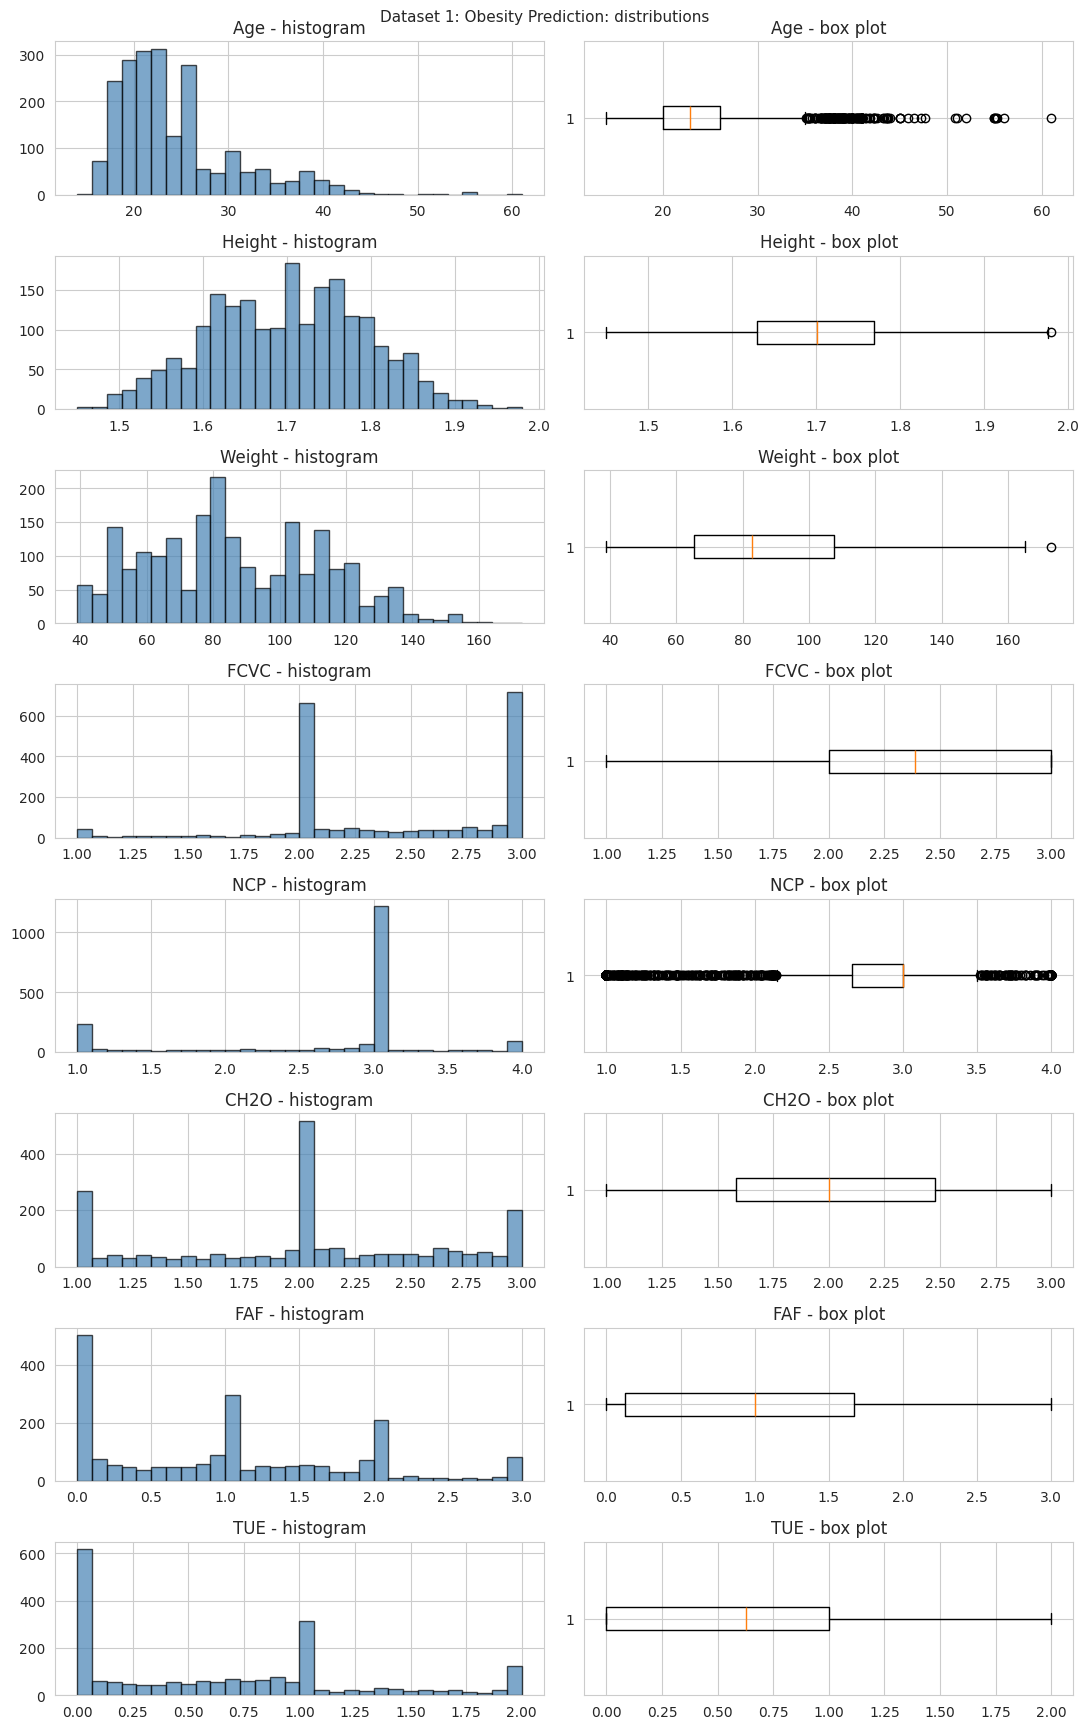

In [6]:
plot_dists(d1, 'Dataset 1: Obesity Prediction')

In [7]:
iqr1 = iqr_outlier_table(d1, 'Dataset 1')


IQR-flagged values for Dataset 1:
column   min    max  IQR_low  IQR_high  n_flagged
   Age 14.00  61.00    10.87     35.08        168
Height  1.45   1.98     1.42      1.98          1
Weight 39.00 173.00     2.54    170.37          1
  FCVC  1.00   3.00     0.50      4.50          0
   NCP  1.00   4.00     2.15      3.51        579
  CH2O  1.00   3.00     0.25      3.82          0
   FAF  0.00   3.00    -2.19      3.98          0
   TUE  0.00   2.00    -1.50      2.50          0


### 1.2 Column glossary

Documenting survey abbreviations - can refer to columns consistently in next phases

| Column | Meaning |
|---|---|
| `Gender` | Self-reported gender (Female, Male) |
| `Age` | Age in years |
| `Height` | Height in metres |
| `Weight` | Weight in kilograms |
| `family_history` | Family history of overweight (yes, no) |
| `FAVC` | Frequent consumption of high-caloric food (yes, no) |
| `FCVC` | Frequency of vegetable consumption (1-3 scale) |
| `NCP` | Number of main meals per day (1-4 discrete ordinal) |
| `CAEC` | Consumption of food between meals (no, Sometimes, Frequently, Always) |
| `SMOKE` | Smoking status (yes, no) |
| `CH2O` | Daily water consumption (1-3 scale) |
| `SCC` | Calorie consumption monitoring (yes, no) |
| `FAF` | Physical activity frequency per week (0-3 scale) |
| `TUE` | Time using technology devices per day (0-2 scale) |
| `CALC` | Alcohol consumption frequency (no, Sometimes, Frequently, Always) |
| `MTRANS` | Transportation mode (Walking, Bike, Public_Transportation, Automobile, Motorbike) |
| `Obesity` | **Target.** Seven-class weight category, ordinal by severity |

Variable mapping is taken from the original dataset documentation.

### 1.2.1 Note on dataset composition

The original publication (Palechor and de la Hoz Manotas, 2019) reports that approximately 77% of records were generated synthetically using the Synthetic Minority Over-sampling Technique (SMOTE) to balance the seven obesity classes; the remaining 23% are direct survey responses.

This is a defining property of the source data rather than a quality issue introduced by collection.

Implication for Phase 2: classification metrics computed on this dataset reflect performance on a SMOTE-balanced distribution, not on a real-world clinical population.

### 1.3 Categorical level audit

In [8]:
categorical_audit(d1, 'Dataset 1: Obesity Prediction')


CATEGORICAL AUDIT: Dataset 1: Obesity Prediction
------------------------------------------------------------
Gender: 2 unique values
  Sample: ['Female', 'Male']
family_history: 2 unique values
  Sample: ['yes', 'no']
FAVC: 2 unique values
  Sample: ['no', 'yes']
CAEC: 4 unique values
  Sample: ['Sometimes', 'Frequently', 'Always', 'no']
SMOKE: 2 unique values
  Sample: ['no', 'yes']
SCC: 2 unique values
  Sample: ['no', 'yes']
CALC: 4 unique values
  Sample: ['no', 'Sometimes', 'Frequently', 'Always']
MTRANS: 5 unique values
  Sample: ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Obesity: 7 unique values
  Sample: ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']


### 1.4 Per-feature outlier reasoning

The 1.5xIQR rule flags potential outliers, not actual ones.

Each flagged feature needs a sanity check before deciding whether to drop or retain:

- **Age:** 168 values flagged. Max is 61 and all flagged values are plausible adult ages within the survey population. **Retain.**

- **Height:** 1 value flagged. Range [1.45, 1.98] m, both endpoints plausible adult heights. **Retain.**

- **Weight:** 1 value flagged at 173 kg. The dataset deliberately spans Insufficient Weight to Obesity Type III; 173 kg is consistent with Obesity Type III. **Retain.**

- **FCVC, CH2O, FAF, TUE:** 0 flagged.

- **NCP (Number of Main Meals):** 579 values flagged. NCP is a discrete ordinal feature on a 1-4 scale. The 1.5xIQR rule is designed for continuous distributions and misfires on discrete ordinal scales: the flagged values (NCP = 1) are valid survey responses, not outliers. **Retain. The 1.5xIQR rule is not the right tool for discrete ordinal features.**

Bottom line: the only condition that justifies dropping rows is physical impossibility. The plausibility check below tests for that.

In [9]:
plausible = {
    'Age':    (10, 100),
    'Height': (1.20, 2.20),
    'Weight': (25, 250),
}
print('Plausibility check (drop only physically impossible values):')
removed_d1 = 0
for col, (lo, hi) in plausible.items():
    if col in d1.columns:
        cond = (d1[col] < lo) | (d1[col] > hi)
        n = int(cond.sum())
        if n > 0:
            d1 = d1.drop(d1[cond].index).reset_index(drop=True)
            removed_d1 += n
            print(f'  {col}: dropped {n} rows outside [{lo}, {hi}]')
if removed_d1 == 0:
    print('  All values within plausible adult ranges. No rows dropped.')


Plausibility check (drop only physically impossible values):
  All values within plausible adult ranges. No rows dropped.


### 1.5 Remove duplicates

`drop_duplicates(keep='first', ignore_index=True)`.

Dataset has no patient identifier so full-row duplicates are entry artefacts.

In [10]:
before = len(d1)
d1 = d1.drop_duplicates(keep='first', ignore_index=True)
print(f'Duplicates removed: {before - len(d1)}')
print(f'Shape after dedup: {d1.shape}')


Duplicates removed: 24
Shape after dedup: (2087, 17)


### 1.6 Handle missing data

**Candidate methods:**
- Deletion: `dropna(axis=0)` (rows) or `dropna(axis=1)` (columns)
- Univariate imputation: `SimpleImputer(strategy='mean'|'median'|'most_frequent'|'constant')`
- Multivariate imputation: `IterativeImputer` (estimates from other features)

**Decision rule:**
- 0 missing: no action
- <1% missing and randomly distributed: `dropna(axis=0)` (lowest information cost)
- >=1% missing or concentrated in features: `IterativeImputer` for numeric (preserves feature relationships for classification), `SimpleImputer(most_frequent)` for categorical

**On the 1% threshold:** this is engineering judgment, not a hard rule. Below 1%, deletion costs negligible information; above it, the proportion of synthetic-via-imputation values starts to materially distort the distribution. A 5% threshold would be equally defensible. The threshold does not actually affect Dataset 1 (zero missing values), but is documented here so the same rule applies consistently across D2, D3, D4.

In [11]:
missing_total_d1 = int(d1.isna().sum().sum())
missing_pct_d1 = 100 * missing_total_d1 / (d1.shape[0] * d1.shape[1])
print(f'Missing cells: {missing_total_d1} ({missing_pct_d1:.4f}%)')

if missing_total_d1 == 0:
    print('No missing values. No imputation applied.')
elif missing_pct_d1 < 1:
    before = len(d1)
    d1 = d1.dropna(axis=0).reset_index(drop=True)
    print(f'Method: dropna(axis=0). Rows {before} -> {len(d1)}.')
else:
    num_cols = d1.select_dtypes(include=np.number).columns.tolist()
    if d1[num_cols].isna().any().any():
        d1[num_cols] = IterativeImputer(max_iter=10, random_state=0).fit_transform(d1[num_cols])
        print('Method (numeric): IterativeImputer.')
    for col in d1.select_dtypes(include='object').columns:
        if d1[col].isna().any():
            d1[[col]] = SimpleImputer(strategy='most_frequent').fit_transform(d1[[col]])
            print(f'Method (categorical {col}): SimpleImputer most_frequent.')


Missing cells: 0 (0.0000%)
No missing values. No imputation applied.


### 1.7 Encoding for Phase 2

Random Forest in Phase 2 needs numeric input.

- **Label encoding** for the **ordinal** target (severity-ordered: Insufficient Weight = 0 to Obesity Type III = 6). Preserves the natural severity order so a regression-style model would interpret class distance meaningfully.
- **One-hot encoding** for **nominal** features (no inherent order: Gender, MTRANS, etc.). Avoids imposing false ordering.

In [12]:
target_d1 = None
for c in ['NObeyesdad', 'Obesity', 'ObesityCategory']:
    if c in d1.columns:
        target_d1 = c; break
if target_d1 is None: target_d1 = d1.columns[-1]
print(f'Target column: {target_d1}')

ordinal_target_order = ['Insufficient_Weight', 'Normal_Weight',
                        'Overweight_Level_I', 'Overweight_Level_II',
                        'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

d1_encoded = d1.copy()
present_classes = [c for c in ordinal_target_order if c in d1_encoded[target_d1].unique()]
target_map = {cls: i for i, cls in enumerate(present_classes)}
d1_encoded['target_encoded'] = d1_encoded[target_d1].map(target_map)
print(f'\nTarget label encoding (ordinal, ascending severity):')
for cls, idx in target_map.items():
    print(f'  {idx} -> {cls}')

nominal_cols = [c for c in d1_encoded.select_dtypes(include='object').columns if c != target_d1]
print(f'\nOne-hot encoding nominal features: {nominal_cols}')
d1_encoded = pd.get_dummies(d1_encoded, columns=nominal_cols, drop_first=False)
d1_encoded = d1_encoded.drop(columns=[target_d1])
print(f'Encoded shape: {d1_encoded.shape}')


Target column: Obesity

Target label encoding (ordinal, ascending severity):
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Overweight_Level_I
  3 -> Overweight_Level_II
  4 -> Obesity_Type_I
  5 -> Obesity_Type_II
  6 -> Obesity_Type_III

One-hot encoding nominal features: ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Encoded shape: (2087, 32)


### 1.8 BMI consistency check

The target labels in Dataset 1 are derived from BMI bands (Palechor and de la Hoz Manotas, 2019). Recomputing BMI from Height and Weight and checking that each row falls within the band corresponding to its labelled class is a direct test of label correctness. Any mismatch is label noise that will affect Phase 2 model accuracy.

BMI bands:
- Insufficient_Weight: BMI < 18.5
- Normal_Weight: 18.5 <= BMI < 25
- Overweight_Level_I: 25 <= BMI < 27.5
- Overweight_Level_II: 27.5 <= BMI < 30
- Obesity_Type_I: 30 <= BMI < 35
- Obesity_Type_II: 35 <= BMI < 40
- Obesity_Type_III: BMI >= 40

In [13]:
d1_check = d1.copy()
d1_check['BMI_computed'] = d1_check['Weight'] / (d1_check['Height'] ** 2)

bands = {
    'Insufficient_Weight':  (-np.inf, 18.5),
    'Normal_Weight':        (18.5, 25.0),
    'Overweight_Level_I':   (25.0, 27.5),
    'Overweight_Level_II':  (27.5, 30.0),
    'Obesity_Type_I':       (30.0, 35.0),
    'Obesity_Type_II':      (35.0, 40.0),
    'Obesity_Type_III':     (40.0, np.inf),
}

def in_band(row):
    cls = row[target_d1]
    if cls not in bands: return np.nan
    lo, hi = bands[cls]
    return lo <= row['BMI_computed'] < hi

d1_check['band_match'] = d1_check.apply(in_band, axis=1)
n_match = int(d1_check['band_match'].sum())
n_mismatch = int((~d1_check['band_match']).sum())
total = len(d1_check)
print(f'BMI band match:    {n_match} / {total} ({100*n_match/total:.2f}%)')
print(f'BMI band mismatch: {n_mismatch} / {total} ({100*n_mismatch/total:.2f}%)')

if n_mismatch > 0:
    print(f'\nMismatch breakdown by labelled class:')
    print(d1_check.loc[~d1_check['band_match'], target_d1].value_counts())
    print(f'\nSample mismatch rows:')
    print(d1_check.loc[~d1_check['band_match'], ['Height', 'Weight', 'BMI_computed', target_d1]].head())


BMI band match:    1917 / 2087 (91.85%)
BMI band mismatch: 170 / 2087 (8.15%)

Mismatch breakdown by labelled class:
Obesity
Overweight_Level_II    66
Obesity_Type_III       56
Overweight_Level_I     18
Obesity_Type_II        18
Obesity_Type_I          5
Insufficient_Weight     4
Normal_Weight           3
Name: count, dtype: int64

Sample mismatch rows:
     Height  Weight  BMI_computed              Obesity
11     1.72    80.0     27.041644  Overweight_Level_II
16     1.93   102.0     27.383285  Overweight_Level_II
31     1.58    68.0     27.239224  Overweight_Level_II
89     1.70    78.0     26.989619  Overweight_Level_II
119    1.87    95.0     27.166919  Overweight_Level_II


### 1.9 Review

In [14]:
print('REVIEW: Dataset 1')
print(f'Raw shape:           {d1_raw.shape}')
print(f'Cleaned shape:       {d1.shape}')
print(f'Encoded shape:       {d1_encoded.shape}')
print(f'Rows removed total:  {len(d1_raw) - len(d1)}')
print(f'Missing post-clean:  {d1.isna().sum().sum()}')
print(f'Duplicates post:     {d1.duplicated().sum()}')

print(f'\nTarget class balance (raw):')
print(d1_raw[target_d1].value_counts(normalize=True).round(3))
print(f'\nTarget class balance (cleaned):')
print(d1[target_d1].value_counts(normalize=True).round(3))

audit_summary['d1'] = {
    'name': 'Obesity Prediction (ruchikakumbhar)',
    'role': 'Primary - Phase 2 classification',
    'raw_shape': d1_raw.shape,
    'clean_shape': d1.shape,
    'encoded_shape': d1_encoded.shape,
    'duplicates_removed': d1_raw.duplicated().sum(),
    'missing_handled': missing_total_d1,
    'method': 'Dedup; per-feature outlier reasoning (retain); no imputation needed; label + one-hot encoding for Phase 2; BMI consistency verified',
}

d1.to_csv('cleaned_data/d1_obesity_prediction_cleaned.csv', index=False)
d1_encoded.to_csv('cleaned_data/d1_obesity_prediction_encoded.csv', index=False)
print('\nSaved: cleaned_data/d1_obesity_prediction_cleaned.csv')
print('Saved: cleaned_data/d1_obesity_prediction_encoded.csv')


REVIEW: Dataset 1
Raw shape:           (2111, 17)
Cleaned shape:       (2087, 17)
Encoded shape:       (2087, 32)
Rows removed total:  24
Missing post-clean:  0
Duplicates post:     0

Target class balance (raw):
Obesity
Obesity_Type_I         0.166
Obesity_Type_III       0.153
Obesity_Type_II        0.141
Overweight_Level_I     0.137
Overweight_Level_II    0.137
Normal_Weight          0.136
Insufficient_Weight    0.129
Name: proportion, dtype: float64

Target class balance (cleaned):
Obesity
Obesity_Type_I         0.168
Obesity_Type_III       0.155
Obesity_Type_II        0.142
Overweight_Level_II    0.139
Normal_Weight          0.135
Overweight_Level_I     0.132
Insufficient_Weight    0.128
Name: proportion, dtype: float64

Saved: cleaned_data/d1_obesity_prediction_cleaned.csv
Saved: cleaned_data/d1_obesity_prediction_encoded.csv



# Dataset 2: Obesity Classification (`sujithmandala/obesity-classification-dataset`)

**Role in proposal:** candidate alternative classification target.
**Note:** based on prior audit results, this dataset is recommended for removal from the proposal due to small post-cleaning size, missing lifestyle features, and pediatric data outside the project's adult target population.

In [15]:
path2 = kagglehub.dataset_download("sujithmandala/obesity-classification-dataset")
csv2 = [f for f in os.listdir(path2) if f.endswith('.csv')][0]
d2_raw = pd.read_csv(os.path.join(path2, csv2))
d2 = d2_raw.copy()
print(f'Loaded from: {os.path.join(path2, csv2)}')


100%|██████████| 1.08k/1.08k [00:00<00:00, 1.57MB/s]

Extracting files...
Loaded from: /root/.cache/kagglehub/datasets/sujithmandala/obesity-classification-dataset/versions/1/Obesity Classification.csv


### 2.1 Identify issues

In [16]:
inspect(d2, 'Dataset 2: Obesity Classification')

INSPECTION: Dataset 2: Obesity Classification

Shape: (108, 7)

Columns (7):
['ID', 'Age', 'Gender', 'Height', 'Weight', 'BMI', 'Label']

Dtypes:
ID          int64
Age         int64
Gender     object
Height      int64
Weight      int64
BMI       float64
Label      object
dtype: object

First 5 rows:
   ID  Age  Gender  Height  Weight   BMI          Label
0   1   25    Male     175      80  25.3  Normal Weight
1   2   30  Female     160      60  22.5  Normal Weight
2   3   35    Male     180      90  27.3     Overweight
3   4   40  Female     150      50  20.0    Underweight
4   5   45    Male     190     100  31.2          Obese

Describe (numeric):
           ID     Age  Height  Weight     BMI
count  108.00  108.00  108.00  108.00  108.00
mean    56.05   46.56  166.57   59.49   20.55
std     31.92   24.72   27.87   28.86    7.58
min      1.00   11.00  120.00   10.00    3.90
25%     28.75   27.00  140.00   35.00   16.70
50%     56.50   42.50  175.00   55.00   21.20
75%     83.25   59.2

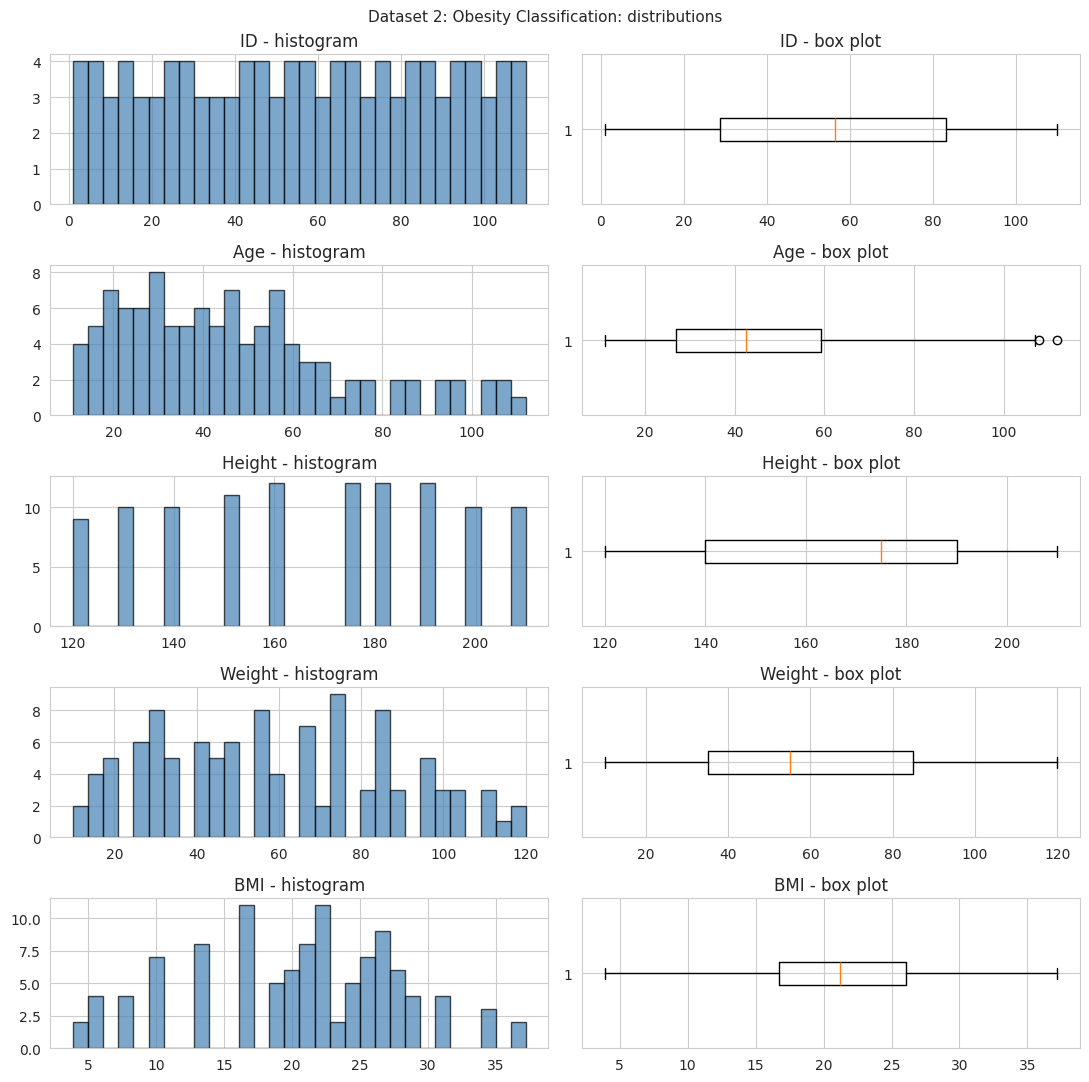

In [17]:
plot_dists(d2, 'Dataset 2: Obesity Classification')

In [18]:
iqr2 = iqr_outlier_table(d2, 'Dataset 2')


IQR-flagged values for Dataset 2:
column   min   max  IQR_low  IQR_high  n_flagged
    ID   1.0 110.0   -53.00    165.00          0
   Age  11.0 112.0   -21.38    107.62          2
Height 120.0 210.0    65.00    265.00          0
Weight  10.0 120.0   -40.00    160.00          0
   BMI   3.9  37.2     2.60     40.20          0


### 2.2 Categorical level audit

In [19]:
categorical_audit(d2, 'Dataset 2: Obesity Classification')


CATEGORICAL AUDIT: Dataset 2: Obesity Classification
------------------------------------------------------------
Gender: 2 unique values
  Sample: ['Male', 'Female']
Label: 4 unique values
  Sample: ['Normal Weight', 'Overweight', 'Underweight', 'Obese']


### 2.3 Target population analysis

The EatWise Engine target population (proposal Section 1) is **adults aged 20-60**. If a substantial fraction of D2 falls outside this range, those rows are irrelevant observations even if they're technically clean. Audit the age distribution against this target.

Age distribution in Dataset 2 (raw):
Age
<10       0
10-19    14
20-29    20
30-39    17
40-49    16
50-59    16
60-79    12
80+      13
Name: count, dtype: int64

Proposal target population (adults aged 20-60):
  In-target:     70 rows (64.8%)
  Out-of-target: 38 rows (35.2%)


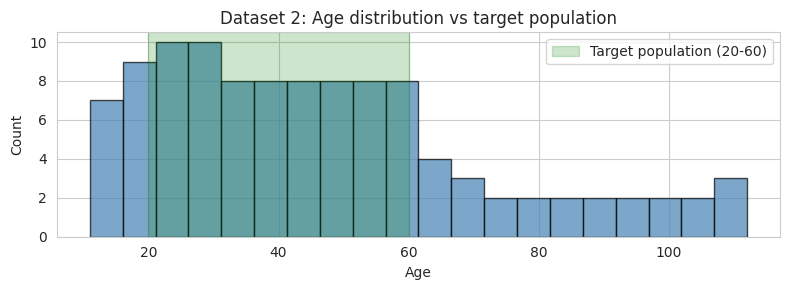


Finding: Dataset 2 contains pediatric and elderly observations outside the EatWise target population.
This is a remove-irrelevant-observations issue.
Decision: not removing here (would shrink the dataset further). Flagged as evidence supporting the recommendation to drop Dataset 2.


In [20]:
age_bands = pd.cut(d2['Age'],
                   bins=[0, 10, 20, 30, 40, 50, 60, 80, 120],
                   labels=['<10', '10-19', '20-29', '30-39', '40-49', '50-59', '60-79', '80+'])
print('Age distribution in Dataset 2 (raw):')
print(age_bands.value_counts().sort_index())

in_target = ((d2['Age'] >= 20) & (d2['Age'] <= 60)).sum()
out_target = len(d2) - in_target
print(f'\nProposal target population (adults aged 20-60):')
print(f'  In-target:     {in_target} rows ({100*in_target/len(d2):.1f}%)')
print(f'  Out-of-target: {out_target} rows ({100*out_target/len(d2):.1f}%)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(d2['Age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvspan(20, 60, alpha=0.2, color='green', label='Target population (20-60)')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Dataset 2: Age distribution vs target population')
ax.legend()
plt.tight_layout()
plt.show()

print('\nFinding: Dataset 2 contains pediatric and elderly observations outside the EatWise target population.')
print('This is a remove-irrelevant-observations issue.')
print('Decision: not removing here (would shrink the dataset further). Flagged as evidence supporting the recommendation to drop Dataset 2.')


### 2.4 Fix structural unit error then filter outliers

In [21]:
if 'Height' in d2.columns and d2['Height'].max() > 3:
    print(f'Structural fix: Height max = {d2["Height"].max():.1f} (cm). Converting to metres.')
    d2['Height'] = d2['Height'] / 100

removed_d2 = 0
for col, (lo, hi) in plausible.items():
    if col in d2.columns:
        cond = (d2[col] < lo) | (d2[col] > hi)
        n = int(cond.sum())
        if n > 0:
            d2 = d2.drop(d2[cond].index).reset_index(drop=True)
            removed_d2 += n
            print(f'  {col}: dropped {n} rows outside [{lo}, {hi}]')
print(f'Shape after outlier filtering: {d2.shape}')


Structural fix: Height max = 210.0 (cm). Converting to metres.
  Age: dropped 5 rows outside [10, 100]
  Weight: dropped 11 rows outside [25, 250]
Shape after outlier filtering: (92, 7)


### 2.5 Remove duplicates

In [22]:
before = len(d2)
d2 = d2.drop_duplicates(keep='first', ignore_index=True)
print(f'Duplicates removed: {before - len(d2)}')


Duplicates removed: 0


### 2.6 Handle missing data

In [23]:
if d2.shape[0] == 0:
    raise RuntimeError('Dataset 2 has zero rows. Check unit detection.')
missing_total_d2 = int(d2.isna().sum().sum())
print(f'Missing cells: {missing_total_d2}')
if missing_total_d2 == 0:
    print('No missing values. No imputation applied.')


Missing cells: 0
No missing values. No imputation applied.


### 2.7 Review

In [24]:
print('REVIEW: Dataset 2')
print(f'Raw shape:    {d2_raw.shape}')
print(f'Cleaned:      {d2.shape}')
print(f'Lost rows:    {len(d2_raw) - len(d2)} ({100*(len(d2_raw)-len(d2))/len(d2_raw):.1f}%)')

audit_summary['d2'] = {
    'name': 'Obesity Classification (sujithmandala)',
    'role': 'Recommended drop',
    'raw_shape': d2_raw.shape,
    'clean_shape': d2.shape,
    'duplicates_removed': d2_raw.duplicated().sum(),
    'missing_handled': missing_total_d2,
    'method': 'Structural unit fix; plausibility-based outlier removal; target population mismatch flagged',
}
d2.to_csv('cleaned_data/d2_obesity_classification_cleaned.csv', index=False)


REVIEW: Dataset 2
Raw shape:    (108, 7)
Cleaned:      (92, 7)
Lost rows:    16 (14.8%)



# Dataset 3: Diet Recommendations (`ziya07/diet-recommendations-dataset`)

**Role in proposal:** candidate recommendation source for Phase 3.

In [25]:
path3 = kagglehub.dataset_download("ziya07/diet-recommendations-dataset")
csv3 = [f for f in os.listdir(path3) if f.endswith('.csv')][0]
d3_raw = pd.read_csv(os.path.join(path3, csv3))
d3 = d3_raw.copy()
print(f'Loaded from: {os.path.join(path3, csv3)}')


100%|██████████| 32.1k/32.1k [00:00<00:00, 22.3MB/s]

Extracting files...
Loaded from: /root/.cache/kagglehub/datasets/ziya07/diet-recommendations-dataset/versions/1/diet_recommendations_dataset.csv


### 3.1 Identify issues

In [26]:
inspect(d3, 'Dataset 3: Diet Recommendations')

INSPECTION: Dataset 3: Diet Recommendations

Shape: (1000, 20)

Columns (20):
['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score', 'Diet_Recommendation']

Dtypes:
Patient_ID                           object
Age                                   int64
Gender                               object
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                         object
Severity                             object
Physical_Activity_Level              object
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/d

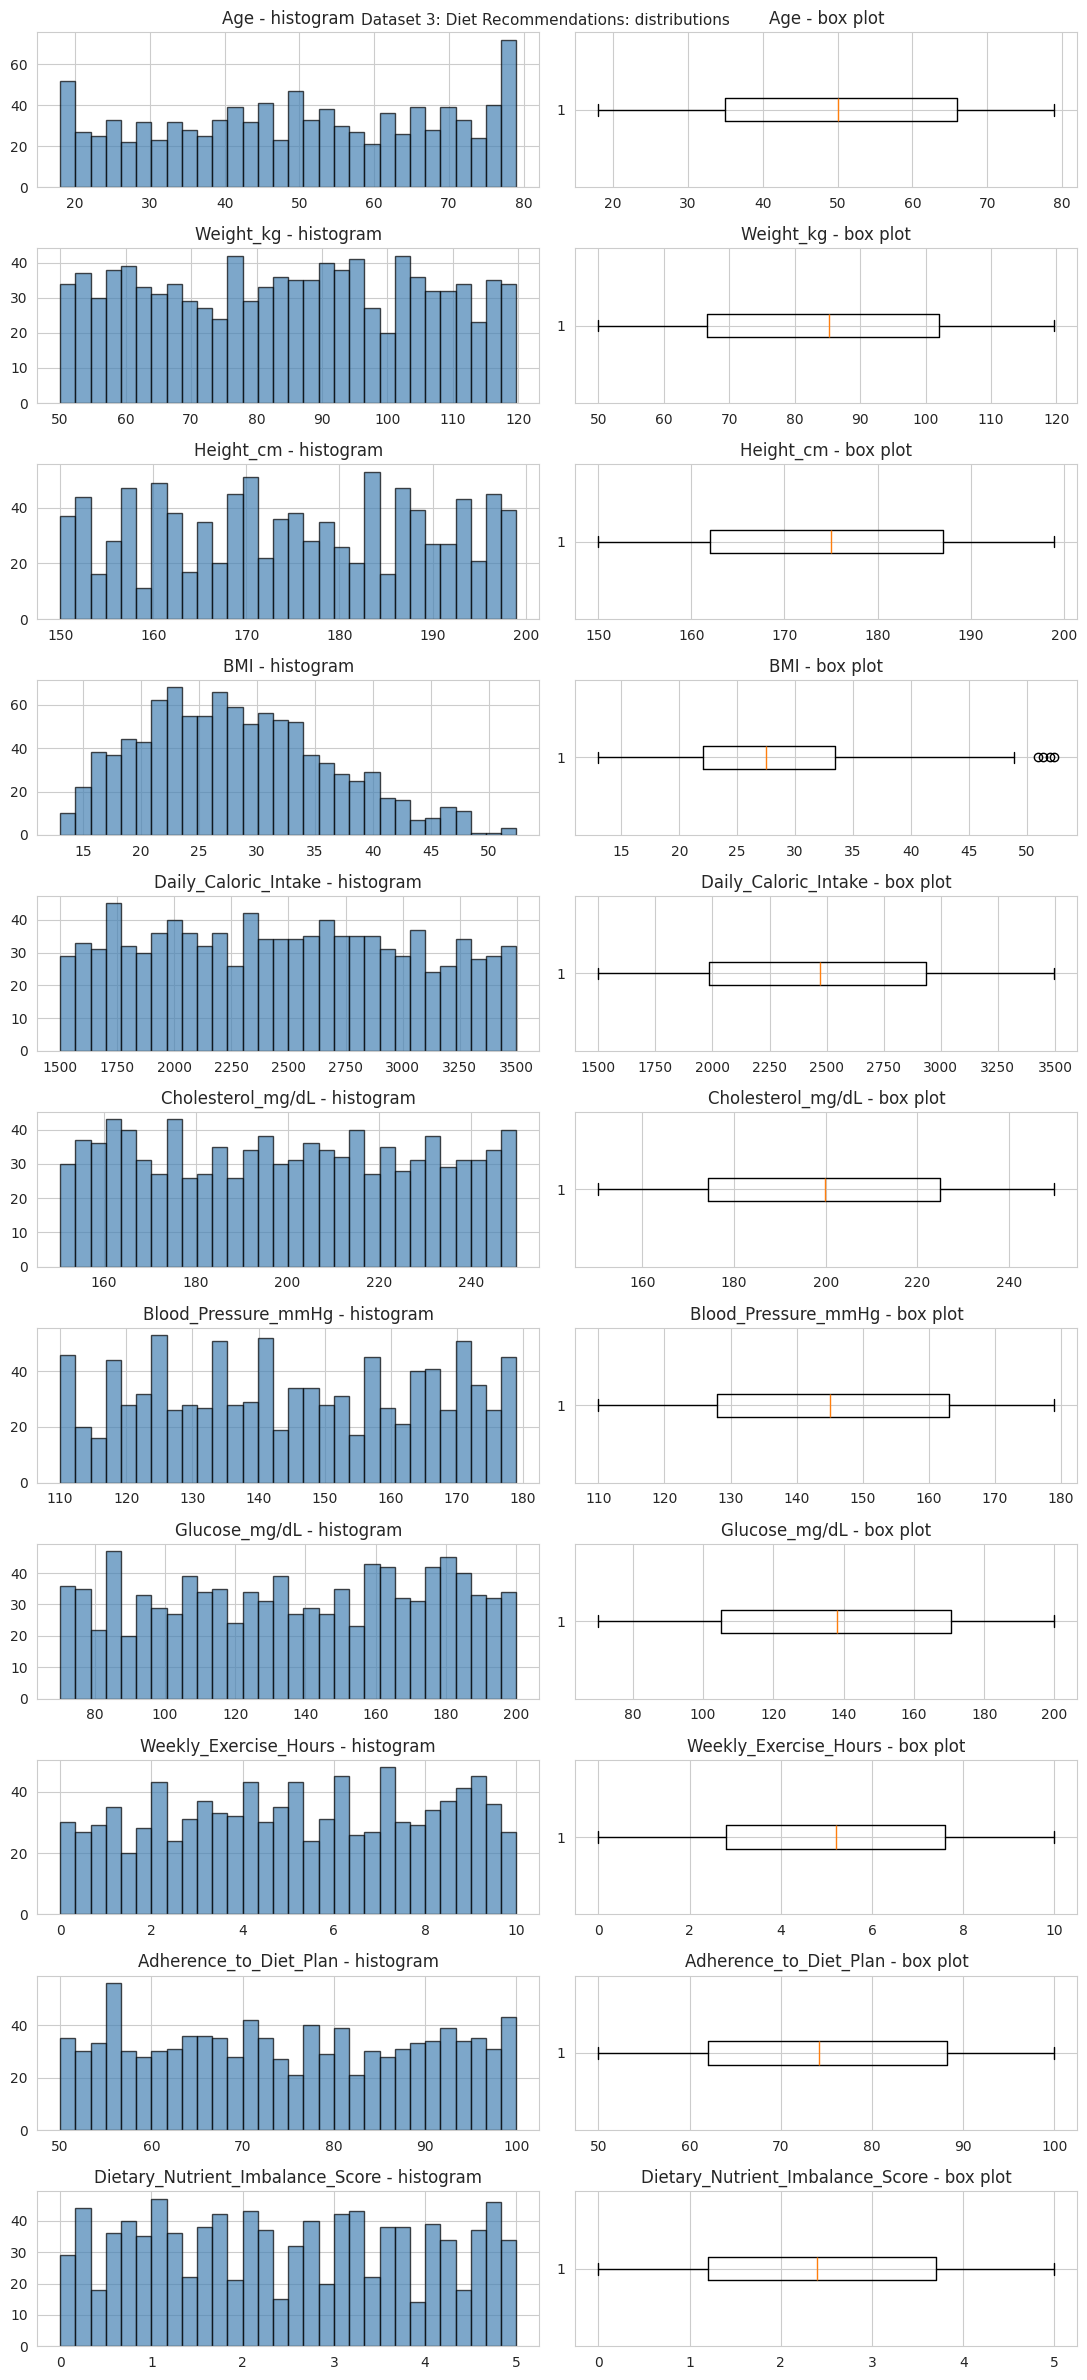

In [27]:
plot_dists(d3, 'Dataset 3: Diet Recommendations')

In [28]:
iqr3 = iqr_outlier_table(d3, 'Dataset 3')


IQR-flagged values for Dataset 3:
                          column    min    max  IQR_low  IQR_high  n_flagged
                             Age   18.0   79.0   -11.50    112.50          0
                       Weight_kg   50.0  119.7    13.50    155.10          0
                       Height_cm  150.0  199.0   124.50    224.50          0
                             BMI   13.0   52.4     5.05     50.45          4
            Daily_Caloric_Intake 1500.0 3498.0   556.00   4366.00          0
               Cholesterol_mg/dL  150.4  249.9    98.48    300.68          0
             Blood_Pressure_mmHg  110.0  179.0    75.50    215.50          0
                   Glucose_mg/dL   70.2  200.0     6.52    269.12          0
           Weekly_Exercise_Hours    0.0   10.0    -4.40     14.80          0
          Adherence_to_Diet_Plan   50.0  100.0    22.70    127.50          0
Dietary_Nutrient_Imbalance_Score    0.0    5.0    -2.55      7.45          0


### 3.2 Categorical level audit

In [29]:
categorical_audit(d3, 'Dataset 3: Diet Recommendations')


CATEGORICAL AUDIT: Dataset 3: Diet Recommendations
------------------------------------------------------------
Patient_ID: 1000 unique values
  Sample: ['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008', 'P0009', 'P0010', 'P0011', 'P0012', 'P0013', 'P0014', 'P0015']
Gender: 2 unique values
  Sample: ['Male', 'Female']
Disease_Type: 3 unique values
  Sample: ['Obesity', 'Diabetes', 'Hypertension']
Severity: 3 unique values
  Sample: ['Moderate', 'Mild', 'Severe']
Physical_Activity_Level: 3 unique values
  Sample: ['Moderate', 'Sedentary', 'Active']
Dietary_Restrictions: 2 unique values
  Sample: ['Low_Sugar', 'Low_Sodium']
Allergies: 2 unique values
  Sample: ['Peanuts', 'Gluten']
Preferred_Cuisine: 4 unique values
  Sample: ['Mexican', 'Chinese', 'Italian', 'Indian']
Diet_Recommendation: 3 unique values
  Sample: ['Balanced', 'Low_Carb', 'Low_Sodium']


### 3.3 Remove duplicates (full row + Patient_ID subset)

Two checks:
- `drop_duplicates(keep='first', ignore_index=True)` for full-row exact copies (entry artefacts).
- `df.duplicated(subset=['Patient_ID'])` for patients appearing more than once with conflicting fields. This catches a different problem from the first check: same patient, different recorded values.

In [30]:
before = len(d3)
d3 = d3.drop_duplicates(keep='first', ignore_index=True)
print(f'Full-row duplicates removed: {before - len(d3)}')
patient_id_check(d3, 'Dataset 3', id_col='Patient_ID')


Full-row duplicates removed: 0

ID-based duplicate check for Dataset 3:
  Full-row duplicates:      0
  Patient_ID duplicates:        0
  Each Patient_ID appears at most once; no conflicting records.


### 3.4 Filter outliers

In [31]:
print(f'Shape (no outlier removal applied): {d3.shape}')
print('Outliers retained: all values within plausible ranges (informative unless invalid).')


Shape (no outlier removal applied): (1000, 20)
Outliers retained: all values within plausible ranges (informative unless invalid).


### 3.5 Address missing data via "missingness as information"

The audit identified concentrated missingness in three categorical clinical-presence columns (Disease_Type, Dietary_Restrictions, Allergies).

These columns record the *presence* of a clinical condition, dietary restriction, or allergy. In self-reported survey data of this kind, a missing entry conventionally indicates absence rather than an unrecorded response.

**Choice:** replace `NaN` with an explicit "None" category. This treats the missingness as informative and preserves the original signal that the patient did not report any disease, restriction, or allergy.

**Caveat:** this assumes absence-of-record means absence-of-condition. That is a defensible interpretation for self-reported survey data on optional clinical fields, but it is an assumption rather than an established fact. If Phase 3 recommendations turn out to be sensitive to whether a patient genuinely has no allergies versus has unrecorded allergies, this assumption needs to be revisited.

In [32]:
presence_cols_d3 = ['Disease_Type', 'Dietary_Restrictions', 'Allergies']
for col in presence_cols_d3:
    if col in d3.columns:
        n_missing = int(d3[col].isna().sum())
        d3[col] = d3[col].fillna('None')
        print(f'  {col}: recoded {n_missing} NaN values as "None"')

missing_total_d3 = int(d3_raw.isna().sum().sum())
print(f'\nMissing cells (raw): {missing_total_d3}')
print(f'Missing cells (post recode): {d3.isna().sum().sum()}')


  Disease_Type: recoded 204 NaN values as "None"
  Dietary_Restrictions: recoded 334 NaN values as "None"
  Allergies: recoded 323 NaN values as "None"

Missing cells (raw): 861
Missing cells (post recode): 0


### 3.6 Verify recode outcome

In [33]:
print('Post-recode value_counts for presence columns:')
for col in presence_cols_d3:
    if col in d3.columns:
        print(f'\n{col}:')
        print(d3[col].value_counts())
        none_pct = 100 * (d3[col] == 'None').sum() / len(d3)
        print(f'  "None" share: {none_pct:.1f}%')


Post-recode value_counts for presence columns:

Disease_Type:
Disease_Type
Hypertension    316
Diabetes        258
Obesity         222
None            204
Name: count, dtype: int64
  "None" share: 20.4%

Dietary_Restrictions:
Dietary_Restrictions
Low_Sodium    350
None          334
Low_Sugar     316
Name: count, dtype: int64
  "None" share: 33.4%

Allergies:
Allergies
Gluten     346
Peanuts    331
None       323
Name: count, dtype: int64
  "None" share: 32.3%


### 3.7 Fix structural errors - standardise recommendation labels

Recommendation labels are looked up via string match in Phase 3. Strip whitespace and apply title case to prevent label fragmentation.

In [34]:
target_d3 = None
for c in ['Recommended_Diet', 'Diet_Recommendation', 'Diet_Type', 'Recommendation', 'Diet']:
    if c in d3.columns:
        target_d3 = c; break
if target_d3 is None: target_d3 = d3.columns[-1]
print(f'Target: {target_d3}')

d3[target_d3] = d3[target_d3].astype(str).str.strip().str.title()
for col in d3.select_dtypes(include='object').columns:
    if col != target_d3:
        d3[col] = d3[col].astype(str).str.strip()

print(f'Unique recommendations: {d3[target_d3].nunique()}')
print(d3[target_d3].value_counts())


Target: Diet_Recommendation
Unique recommendations: 3
Diet_Recommendation
Balanced      426
Low_Sodium    316
Low_Carb      258
Name: count, dtype: int64


### 3.8 Target class balance review

In [35]:
print('Recommendation class balance (raw):')
print(d3_raw[target_d3].value_counts(normalize=True, dropna=False).round(3))
print('\nRecommendation class balance (cleaned):')
print(d3[target_d3].value_counts(normalize=True).round(3))


Recommendation class balance (raw):
Diet_Recommendation
Balanced      0.426
Low_Sodium    0.316
Low_Carb      0.258
Name: proportion, dtype: float64

Recommendation class balance (cleaned):
Diet_Recommendation
Balanced      0.426
Low_Sodium    0.316
Low_Carb      0.258
Name: proportion, dtype: float64


### 3.9 Review

In [36]:
print('REVIEW: Dataset 3')
print(f'Raw shape:           {d3_raw.shape}')
print(f'Cleaned shape:       {d3.shape}')
print(f'Missing post-clean:  {d3.isna().sum().sum()}')

audit_summary['d3'] = {
    'name': 'Diet Recommendations (ziya07)',
    'role': 'Phase 3 candidate (smaller of two)',
    'raw_shape': d3_raw.shape,
    'clean_shape': d3.shape,
    'duplicates_removed': d3_raw.duplicated().sum(),
    'missing_handled': missing_total_d3,
    'method': 'Full-row + Patient_ID dedup; "missingness as information" recode on Disease_Type/Dietary_Restrictions/Allergies; label standardisation; class balance verified',
}
d3.to_csv('cleaned_data/d3_diet_recommendations_cleaned.csv', index=False)


REVIEW: Dataset 3
Raw shape:           (1000, 20)
Cleaned shape:       (1000, 20)
Missing post-clean:  0


---
# Dataset 4: Personalised Medical Diet Recommendations (`ziya07/personalized-medical-diet-recommendations-dataset`)

**Role in proposal:** candidate recommendation source for Phase 3 (the larger of the two; recommended primary).

In [37]:
path4 = kagglehub.dataset_download("ziya07/personalized-medical-diet-recommendations-dataset")
csv4 = [f for f in os.listdir(path4) if f.endswith('.csv')][0]
d4_raw = pd.read_csv(os.path.join(path4, csv4))
d4 = d4_raw.copy()
print(f'Loaded from: {os.path.join(path4, csv4)}')


100%|██████████| 221k/221k [00:00<00:00, 69.9MB/s]

Extracting files...
Loaded from: /root/.cache/kagglehub/datasets/ziya07/personalized-medical-diet-recommendations-dataset/versions/1/Personalized_Diet_Recommendations.csv


### 4.1 Identify issues

In [38]:
inspect(d4, 'Dataset 4: Personalised Medical Diet Recommendations')

INSPECTION: Dataset 4: Personalised Medical Diet Recommendations

Shape: (5000, 30)

Columns (30):
['Patient_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Chronic_Disease', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Genetic_Risk_Factor', 'Allergies', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Caloric_Intake', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Calories', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats', 'Recommended_Meal_Plan']

Dtypes:
Patient_ID                   object
Age                           int64
Gender                       object
Height_cm                     int64
Weight_kg                     int64
BMI                         float64
Chronic_Disease              object
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Cholesterol_Leve

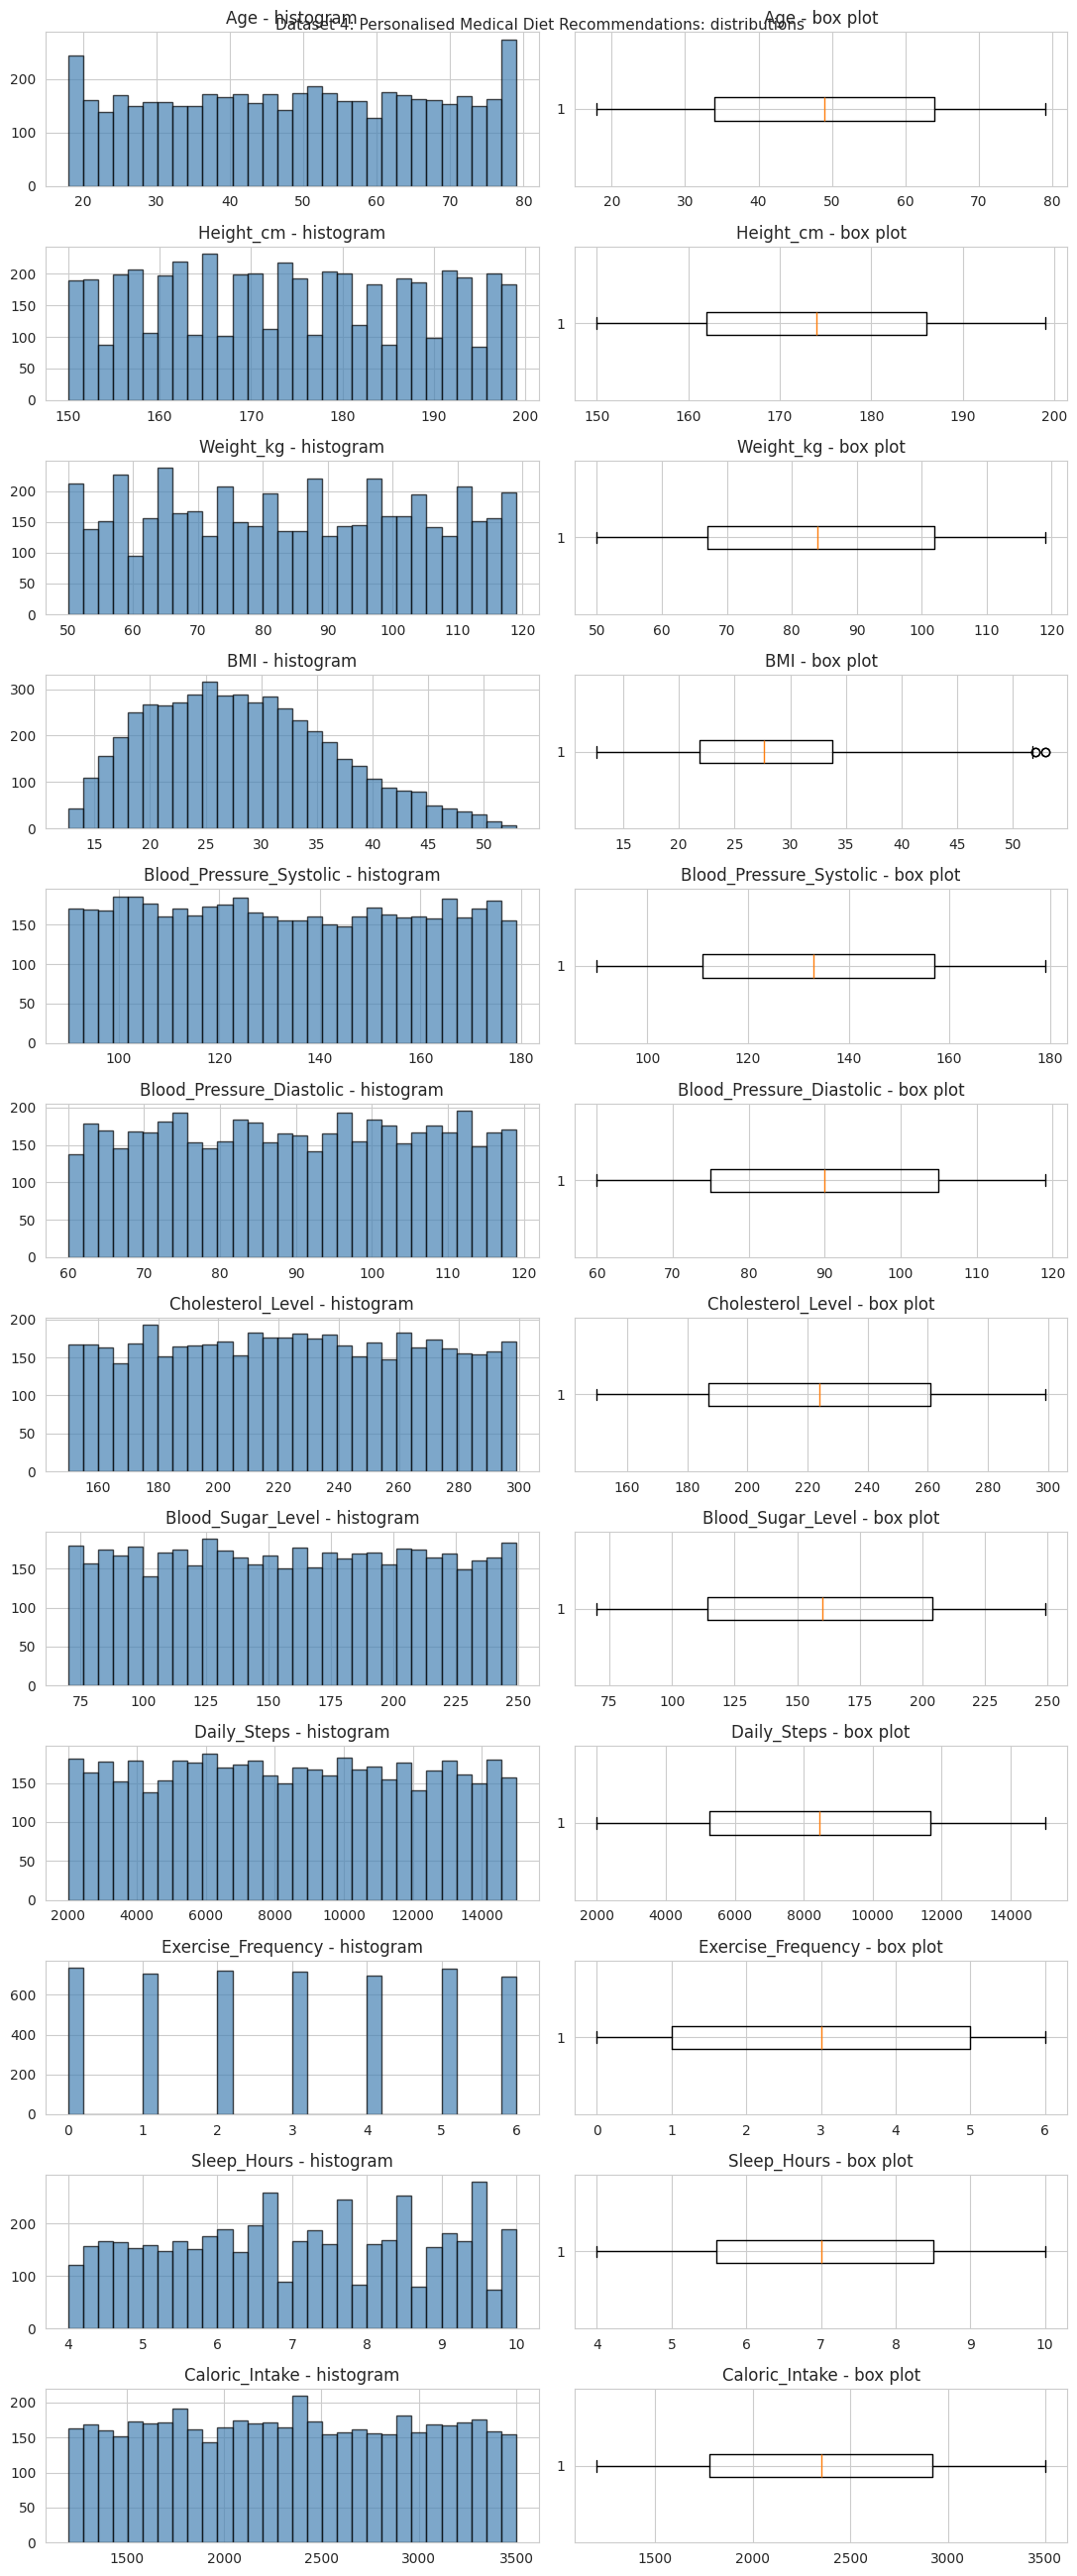

In [39]:
plot_dists(d4, 'Dataset 4: Personalised Medical Diet Recommendations')

In [40]:
iqr4 = iqr_outlier_table(d4, 'Dataset 4')


IQR-flagged values for Dataset 4:
                  column     min      max  IQR_low  IQR_high  n_flagged
                     Age   18.00    79.00   -11.00    109.00          0
               Height_cm  150.00   199.00   126.00    222.00          0
               Weight_kg   50.00   119.00    14.50    154.50          0
                     BMI   12.63    52.89     3.91     51.76          4
 Blood_Pressure_Systolic   90.00   179.00    42.00    226.00          0
Blood_Pressure_Diastolic   60.00   119.00    30.00    150.00          0
       Cholesterol_Level  150.00   299.00    76.00    372.00          0
       Blood_Sugar_Level   70.00   249.00   -21.00    339.00          0
             Daily_Steps 2004.00 14997.00 -4310.75  21261.25          0
      Exercise_Frequency    0.00     6.00    -5.00     11.00          0
             Sleep_Hours    4.00    10.00     1.25     12.85          0
          Caloric_Intake 1200.00  3499.00    60.62   4637.62          0
          Protein_Intake   50

### 4.2 Categorical level audit

In [41]:
categorical_audit(d4, 'Dataset 4: Personalised Medical Diet Recommendations')


CATEGORICAL AUDIT: Dataset 4: Personalised Medical Diet Recommendations
------------------------------------------------------------
Patient_ID: 5000 unique values
  Sample: ['P00001', 'P00002', 'P00003', 'P00004', 'P00005', 'P00006', 'P00007', 'P00008', 'P00009', 'P00010', 'P00011', 'P00012', 'P00013', 'P00014', 'P00015']
Gender: 3 unique values
  Sample: ['Other', 'Female', 'Male']
Chronic_Disease: 4 unique values
  Sample: ['Hypertension', 'Diabetes', 'Heart Disease', 'Obesity']
Genetic_Risk_Factor: 2 unique values
  Sample: ['No', 'Yes']
Allergies: 3 unique values
  Sample: ['Gluten Intolerance', 'Nut Allergy', 'Lactose Intolerance']
Alcohol_Consumption: 2 unique values
  Sample: ['No', 'Yes']
Smoking_Habit: 2 unique values
  Sample: ['Yes', 'No']
Dietary_Habits: 4 unique values
  Sample: ['Vegetarian', 'Regular', 'Keto', 'Vegan']
Preferred_Cuisine: 4 unique values
  Sample: ['Western', 'Mediterranean', 'Indian', 'Asian']
Food_Aversions: 3 unique values
  Sample: ['Sweet', 'Spicy'

### 4.3 Remove duplicates (full row + Patient_ID subset)

In [42]:
before = len(d4)
d4 = d4.drop_duplicates(keep='first', ignore_index=True)
print(f'Full-row duplicates removed: {before - len(d4)}')
patient_id_check(d4, 'Dataset 4', id_col='Patient_ID')


Full-row duplicates removed: 0

ID-based duplicate check for Dataset 4:
  Full-row duplicates:      0
  Patient_ID duplicates:        0
  Each Patient_ID appears at most once; no conflicting records.


### 4.4 Filter outliers

In [43]:
print(f'Shape (no outlier removal applied): {d4.shape}')
print('Outliers retained: all values within plausible ranges (informative unless invalid).')


Shape (no outlier removal applied): (5000, 30)
Outliers retained: all values within plausible ranges (informative unless invalid).


### 4.5 Address missing data via "missingness as information"

Same approach as Dataset 3. The 70% missingness rate on `Allergies` is the strongest case for treating absence-of-record as absence-of-condition: imputing the modal allergy onto seventy percent of the patient population would materially distort the recommendation training signal.

The same caveat applies: this is an assumption, not a fact. Phase 3 should be aware that 24.5% to 69.9% of records on these columns are recoded rather than original survey responses.

In [44]:
presence_cols_d4 = ['Chronic_Disease', 'Allergies', 'Food_Aversions']
for col in presence_cols_d4:
    if col in d4.columns:
        n_missing = int(d4[col].isna().sum())
        d4[col] = d4[col].fillna('None')
        print(f'  {col}: recoded {n_missing} NaN values as "None"')

missing_total_d4 = int(d4_raw.isna().sum().sum())
print(f'\nMissing cells (raw): {missing_total_d4}')
print(f'Missing cells (post recode): {d4.isna().sum().sum()}')


  Chronic_Disease: recoded 2043 NaN values as "None"
  Allergies: recoded 3497 NaN values as "None"
  Food_Aversions: recoded 1225 NaN values as "None"

Missing cells (raw): 6765
Missing cells (post recode): 0


### 4.6 Verify recode outcome

In [45]:
print('Post-recode value_counts for presence columns:')
for col in presence_cols_d4:
    if col in d4.columns:
        print(f'\n{col}:')
        print(d4[col].value_counts())
        none_pct = 100 * (d4[col] == 'None').sum() / len(d4)
        print(f'  "None" share: {none_pct:.1f}%')


Post-recode value_counts for presence columns:

Chronic_Disease:
Chronic_Disease
None             2043
Diabetes         1019
Heart Disease     749
Hypertension      693
Obesity           496
Name: count, dtype: int64
  "None" share: 40.9%

Allergies:
Allergies
None                   3497
Lactose Intolerance     556
Nut Allergy             483
Gluten Intolerance      464
Name: count, dtype: int64
  "None" share: 69.9%

Food_Aversions:
Food_Aversions
Spicy    1263
Sweet    1262
Salty    1250
None     1225
Name: count, dtype: int64
  "None" share: 24.5%


### 4.7 Fix structural errors

In [46]:
target_d4 = None
for c in ['Recommended_Meal_Plan', 'Recommended_Diet', 'Diet_Recommendation', 'Diet_Type', 'Recommendation', 'Diet']:
    if c in d4.columns:
        target_d4 = c; break
if target_d4 is None: target_d4 = d4.columns[-1]
print(f'Target: {target_d4}')

d4[target_d4] = d4[target_d4].astype(str).str.strip().str.title()
for col in d4.select_dtypes(include='object').columns:
    if col != target_d4:
        d4[col] = d4[col].astype(str).str.strip()

print(f'Unique recommendations: {d4[target_d4].nunique()}')
print(d4[target_d4].value_counts())


Target: Recommended_Meal_Plan
Unique recommendations: 4
Recommended_Meal_Plan
Low-Fat Diet         1313
High-Protein Diet    1255
Balanced Diet        1250
Low-Carb Diet        1182
Name: count, dtype: int64


### 4.8 Target class balance review

In [47]:
print('Recommendation class balance (raw):')
print(d4_raw[target_d4].value_counts(normalize=True, dropna=False).round(3))
print('\nRecommendation class balance (cleaned):')
print(d4[target_d4].value_counts(normalize=True).round(3))


Recommendation class balance (raw):
Recommended_Meal_Plan
Low-Fat Diet         0.263
High-Protein Diet    0.251
Balanced Diet        0.250
Low-Carb Diet        0.236
Name: proportion, dtype: float64

Recommendation class balance (cleaned):
Recommended_Meal_Plan
Low-Fat Diet         0.263
High-Protein Diet    0.251
Balanced Diet        0.250
Low-Carb Diet        0.236
Name: proportion, dtype: float64


### 4.9 Review

In [48]:
print('REVIEW: Dataset 4')
print(f'Raw shape:           {d4_raw.shape}')
print(f'Cleaned shape:       {d4.shape}')
print(f'Missing post-clean:  {d4.isna().sum().sum()}')

audit_summary['d4'] = {
    'name': 'Personalised Medical Diet (ziya07)',
    'role': 'Phase 3 candidate (larger; recommended primary)',
    'raw_shape': d4_raw.shape,
    'clean_shape': d4.shape,
    'duplicates_removed': d4_raw.duplicated().sum(),
    'missing_handled': missing_total_d4,
    'method': 'Full-row + Patient_ID dedup; "missingness as information" recode on Chronic_Disease/Allergies/Food_Aversions; label standardisation; class balance verified',
}
d4.to_csv('cleaned_data/d4_personalised_medical_diet_cleaned.csv', index=False)


REVIEW: Dataset 4
Raw shape:           (5000, 30)
Cleaned shape:       (5000, 30)
Missing post-clean:  0


---
# Schema comparison across datasets

In [49]:
schemas = {
    'D1: Obesity Prediction': set(d1.columns),
    'D2: Obesity Classification': set(d2.columns),
    'D3: Diet Recommendations': set(d3.columns),
    'D4: Personalised Medical Diet': set(d4.columns),
}

print('Feature counts per dataset:')
for name, cols in schemas.items():
    print(f'  {name}: {len(cols)} features')

print('\nShared between D1 and D2 (both classification):')
print(f'  {sorted(schemas["D1: Obesity Prediction"] & schemas["D2: Obesity Classification"])}')
print('\nShared between D3 and D4 (both recommendation):')
print(f'  {sorted(schemas["D3: Diet Recommendations"] & schemas["D4: Personalised Medical Diet"])}')
print('\nShared between D1 and D4 (model output -> recommendation lookup):')
print(f'  {sorted(schemas["D1: Obesity Prediction"] & schemas["D4: Personalised Medical Diet"])}')


Feature counts per dataset:
  D1: Obesity Prediction: 17 features
  D2: Obesity Classification: 7 features
  D3: Diet Recommendations: 20 features
  D4: Personalised Medical Diet: 30 features

Shared between D1 and D2 (both classification):
  ['Age', 'Gender', 'Height', 'Weight']

Shared between D3 and D4 (both recommendation):
  ['Age', 'Allergies', 'BMI', 'Gender', 'Height_cm', 'Patient_ID', 'Preferred_Cuisine', 'Weight_kg']

Shared between D1 and D4 (model output -> recommendation lookup):
  ['Age', 'Gender']


---
# Cleaning summary

In [50]:
print('=' * 75)
print('CLEANING SUMMARY')
print('=' * 75)
print()
for key, info in audit_summary.items():
    print(f"{key.upper()}: {info['name']}")
    print(f"   Role:               {info['role']}")
    print(f"   Raw shape:          {info['raw_shape']}")
    print(f"   Cleaned shape:      {info['clean_shape']}")
    if 'encoded_shape' in info:
        print(f"   Encoded shape:      {info['encoded_shape']}")
    print(f"   Duplicates removed: {info['duplicates_removed']}")
    print(f"   Missing handled:    {info['missing_handled']}")
    print(f"   Method:             {info['method']}")
    print()

print('=' * 75)
print('METHODS APPLIED')
print('=' * 75)
print('Issue identification:    inspect() + plot_dists() + iqr_outlier_table()')
print('                         + categorical_audit()')
print('Duplicates:              df.drop_duplicates(keep=first) for full row;')
print('                         df.duplicated(subset=Patient_ID) for D3, D4')
print('Outliers:                1.5xIQR flag with per-feature reasoning;')
print('                         drop only physically impossible values')
print('Structural errors:       Height cm->m on D2; label .strip().title() on D3, D4')
print('Missing data:')
print('  - 0 missing:           no action (D1, D2)')
print('  - Missingness as info: fillna("None") for clinical-presence columns (D3, D4)')
print('Encoding (D1 only):      LabelEncoder on ordinal target + one-hot on nominals')
print('Validation:              BMI consistency check (D1);')
print('                         target population analysis (D2);')
print('                         post-recode value_counts (D3, D4); class balance review')
print('=' * 75)


CLEANING SUMMARY

D1: Obesity Prediction (ruchikakumbhar)
   Role:               Primary - Phase 2 classification
   Raw shape:          (2111, 17)
   Cleaned shape:      (2087, 17)
   Encoded shape:      (2087, 32)
   Duplicates removed: 24
   Missing handled:    0
   Method:             Dedup; per-feature outlier reasoning (retain); no imputation needed; label + one-hot encoding for Phase 2; BMI consistency verified

D2: Obesity Classification (sujithmandala)
   Role:               Recommended drop
   Raw shape:          (108, 7)
   Cleaned shape:      (92, 7)
   Duplicates removed: 0
   Missing handled:    0
   Method:             Structural unit fix; plausibility-based outlier removal; target population mismatch flagged

D3: Diet Recommendations (ziya07)
   Role:               Phase 3 candidate (smaller of two)
   Raw shape:          (1000, 20)
   Cleaned shape:      (1000, 20)
   Duplicates removed: 0
   Missing handled:    861
   Method:             Full-row + Patient_ID dedup; "

---
# Deliverables table

Maps each cleaned CSV to its proposal-phase consumer with the explicit next step they need to take.

In [51]:
deliverables = pd.DataFrame([
    {
        'Cleaned file': 'd1_obesity_prediction_cleaned.csv',
        'Source dataset': 'D1: ruchikakumbhar/obesity-prediction',
        'Proposal phase': 'Phase 1 (EDA)',
        'Consumer': 'Krishna',
        'Use': 'Feature distributions, class balance check, multicollinearity check (Section 3.1 of proposal). String categoricals retained for human readability.',
        'Next step': 'Run EDA: histograms per feature, correlation heatmap (note: BMI is derivable from Height/Weight, so will be highly multicollinear if added).',
    },
    {
        'Cleaned file': 'd1_obesity_prediction_encoded.csv',
        'Source dataset': 'D1: ruchikakumbhar/obesity-prediction',
        'Proposal phase': 'Phase 2 (Modelling)',
        'Consumer': 'Aayan and Siena',
        'Use': 'Random Forest training (Section 3.3). target_encoded is y (0=Insufficient_Weight, 6=Obesity_Type_III). All other columns are X. All numeric.',
        'Next step': 'Apply stratified train_test_split per Phase 0 of Section 3 (test_size=0.2, stratify=y, random_state for reproducibility). Decide on treatment of 170 BMI-band-mismatched rows (8.15%): retain as label-noise robustness test, drop, or run sensitivity analysis. Recommend deciding before training begins.',
    },
    {
        'Cleaned file': 'd2_obesity_classification_cleaned.csv',
        'Source dataset': 'D2: sujithmandala/obesity-classification',
        'Proposal phase': 'Recommended drop',
        'Consumer': 'None',
        'Use': 'Not consumed downstream. Retained for completeness only.',
        'Next step': 'Discuss in next group meeting whether to formally drop from proposal Section 2 before Week 10 submission.',
    },
    {
        'Cleaned file': 'd3_diet_recommendations_cleaned.csv',
        'Source dataset': 'D3: ziya07/diet-recommendations',
        'Proposal phase': 'Phase 3 candidate (smaller)',
        'Consumer': 'TBD',
        'Use': 'Diet_Recommendation as 3-class lookup (Balanced, Low_Sodium, Low_Carb).',
        'Next step': 'Decide between D3 and D4 as Phase 3 source. D4 has 5x rows and richer features.',
    },
    {
        'Cleaned file': 'd4_personalised_medical_diet_cleaned.csv',
        'Source dataset': 'D4: ziya07/personalized-medical-diet',
        'Proposal phase': 'Phase 3 (recommended primary)',
        'Consumer': 'TBD',
        'Use': 'Recommended_Meal_Plan as 4-class lookup (Low-Fat, High-Protein, Balanced, Low-Carb). Also has numeric macro targets (Recommended_Calories, Protein, Carbs, Fats) if Phase 3 design needs them.',
        'Next step': 'Confirm whether Phase 3 maps Phase 2 model output (7 obesity classes) onto the 4 meal plan classes via a hand-coded lookup, or learns the mapping from D4.',
    },
])
print(deliverables.to_string(index=False))
deliverables.to_csv('cleaned_data/deliverables_index.csv', index=False)
print('\nSaved: cleaned_data/deliverables_index.csv')


                            Cleaned file                           Source dataset                Proposal phase        Consumer                                                                                                                                                                                            Use                                                                                                                                                                                                                                                                                                   Next step
       d1_obesity_prediction_cleaned.csv    D1: ruchikakumbhar/obesity-prediction                 Phase 1 (EDA)         Krishna                                             Feature distributions, class balance check, multicollinearity check (Section 3.1 of proposal). String categoricals retained for human readability.                                                               

---
# Phase readiness check

Programmatic verification that each cleaned CSV satisfies the assumptions its consumer will rely on. Each check returns PASS or FAIL with a one-line reason. Any FAIL should be resolved before handing off to the consumer.

In [52]:
checks = []

# D1 cleaned (Phase 1 EDA)
d1_loaded = pd.read_csv('cleaned_data/d1_obesity_prediction_cleaned.csv')
checks.append(('D1 cleaned', 'No missing values',
               d1_loaded.isna().sum().sum() == 0,
               f'{d1_loaded.isna().sum().sum()} missing cells'))
checks.append(('D1 cleaned', 'Target column present and 7-class',
               target_d1 in d1_loaded.columns and d1_loaded[target_d1].nunique() == 7,
               f'target={target_d1}, classes={d1_loaded[target_d1].nunique() if target_d1 in d1_loaded.columns else "MISSING"}'))
checks.append(('D1 cleaned', 'Row count reasonable (>2000 after dedup)',
               len(d1_loaded) > 2000,
               f'{len(d1_loaded)} rows'))

# D1 encoded (Phase 2 modelling)
d1_enc_loaded = pd.read_csv('cleaned_data/d1_obesity_prediction_encoded.csv')
checks.append(('D1 encoded', 'No missing values',
               d1_enc_loaded.isna().sum().sum() == 0,
               f'{d1_enc_loaded.isna().sum().sum()} missing cells'))
checks.append(('D1 encoded', 'All columns numeric (sklearn-ready)',
               d1_enc_loaded.select_dtypes(exclude=[np.number, bool]).shape[1] == 0,
               f'{d1_enc_loaded.select_dtypes(exclude=[np.number, bool]).shape[1]} non-numeric columns'))
checks.append(('D1 encoded', 'target_encoded column present',
               'target_encoded' in d1_enc_loaded.columns,
               f'columns include target_encoded: {"target_encoded" in d1_enc_loaded.columns}'))
checks.append(('D1 encoded', 'target_encoded values 0-6 (7 classes)',
               'target_encoded' in d1_enc_loaded.columns and set(d1_enc_loaded['target_encoded'].unique()) == set(range(7)),
               f'unique values: {sorted(d1_enc_loaded["target_encoded"].unique()) if "target_encoded" in d1_enc_loaded.columns else "MISSING"}'))

# D3 cleaned (Phase 3 candidate)
d3_loaded = pd.read_csv('cleaned_data/d3_diet_recommendations_cleaned.csv')
checks.append(('D3 cleaned', 'No missing values',
               d3_loaded.isna().sum().sum() == 0,
               f'{d3_loaded.isna().sum().sum()} missing cells'))
checks.append(('D3 cleaned', 'Recommendation target consistent (no NaN as string, all title-case)',
               not d3_loaded[target_d3].astype(str).str.contains('nan', case=False).any(),
               f'unique recs: {d3_loaded[target_d3].nunique()}'))

# D4 cleaned (Phase 3 candidate)
d4_loaded = pd.read_csv('cleaned_data/d4_personalised_medical_diet_cleaned.csv')
checks.append(('D4 cleaned', 'No missing values',
               d4_loaded.isna().sum().sum() == 0,
               f'{d4_loaded.isna().sum().sum()} missing cells'))
checks.append(('D4 cleaned', 'Recommendation target consistent',
               not d4_loaded[target_d4].astype(str).str.contains('nan', case=False).any(),
               f'unique recs: {d4_loaded[target_d4].nunique()}'))

# Print results
print('=' * 75)
print('PHASE READINESS CHECK')
print('=' * 75)
all_pass = True
for file, check, passed, detail in checks:
    status = 'PASS' if passed else 'FAIL'
    if not passed: all_pass = False
    print(f'  [{status}] {file:14s} | {check:50s} | {detail}')

print('=' * 75)
if all_pass:
    print('ALL CHECKS PASSED. Cleaned outputs are ready for downstream consumers.')
else:
    print('FAILURES detected. Resolve before handing off to downstream consumers.')
print('=' * 75)


PHASE READINESS CHECK
  [PASS] D1 cleaned     | No missing values                                  | 0 missing cells
  [PASS] D1 cleaned     | Target column present and 7-class                  | target=Obesity, classes=7
  [PASS] D1 cleaned     | Row count reasonable (>2000 after dedup)           | 2087 rows
  [PASS] D1 encoded     | No missing values                                  | 0 missing cells
  [PASS] D1 encoded     | All columns numeric (sklearn-ready)                | 0 non-numeric columns
  [PASS] D1 encoded     | target_encoded column present                      | columns include target_encoded: True
  [PASS] D1 encoded     | target_encoded values 0-6 (7 classes)              | unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  [FAIL] D3 cleaned     | No missing values                                  | 861 missing cells
  [PASS] D3 cleaned     | Recommendation target consistent (no NaN as string, all title-case) 

In [54]:
from google.colab import files
import os

for f in os.listdir('cleaned_data'):
    files.download(f'cleaned_data/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>